<a href="https://colab.research.google.com/github/njones61/xslope/blob/main/docs/lim_eq/xslope_lem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XSLOPE - Limit Equilibrium Method

This notebook illustrates how to use xslope to solve basic slope stability problems using the limit equilibrium method.

## Install xslope and import functions

In [1]:
# Install the xslope package
# - Basic install (limit equilibrium only): pip install xslope
# - Full install (with FEM features): pip install xslope[fem]

%%capture
!pip install xslope

In [2]:
# Import functions

import xslope as xslope

from xslope.global_config import non_circ
from xslope.slice import generate_slices
from xslope.fileio import load_slope_data, load_data_from_pickle
from xslope.plot import plot_circular_search_results, plot_inputs, plot_solution, plot_noncircular_search_results
from xslope.solve import solve_selected, solve_all
from xslope.search import circular_search, noncircular_search
from xslope.reliability import reliability_analysis, plot_reliability_results

## Upload Excel Template

In [6]:
# Upload excel input template for selected problem

from google.colab import files
upload = files.upload()
file_name = list(upload.keys())[0]

Saving input_template_griffiths1_6 copy.xlsx to input_template_griffiths1_6 copy.xlsx


## Load slope data

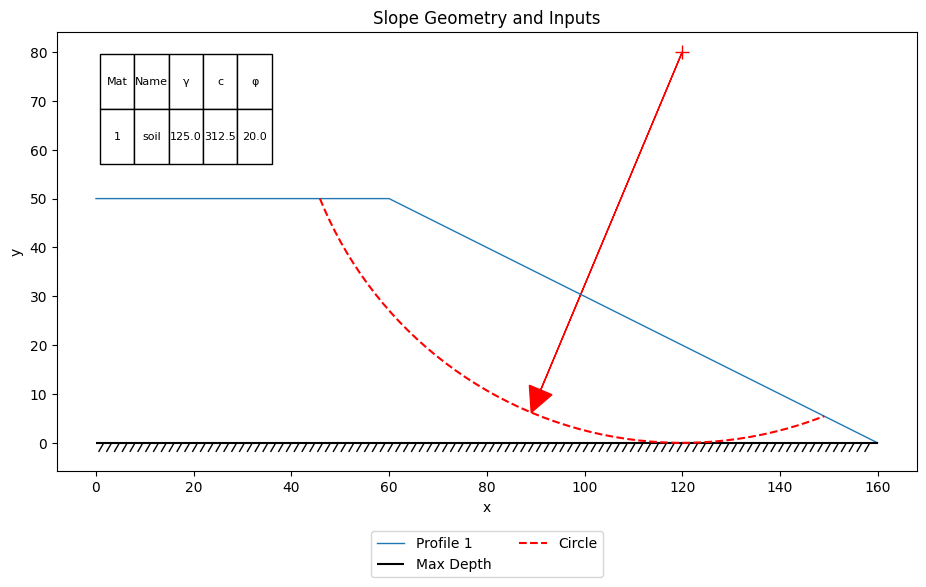

In [38]:
slope_data = load_slope_data(file_name)
plot_inputs(slope_data)

In [1]:
# @title Select Options {"run":"auto"}
method = "spencer" # @param ["oms","bishop","janbu","corps_engineers","lowe_karafiath","spencer"]
num_slices = 20 # @param {"type":"integer"}
analysis_type = "auto_search" # @param ["single_surface","all_methods", "auto_search","reliability"]
surface_type = "circular" # @param ["circular","non_circular"]
rapid_drawdown = False # @param {"type":"boolean"}
save_png = True # @param {"type":"boolean","placeholder":"True"}


## Find and plot solution

In [47]:
if analysis_type == 'single_surface' or analysis_type == 'all_methods' : # selected surface with one or multiple methods
  if surface_type == "circular":
    circle = slope_data['circles'][0] if slope_data['circular'] else None
    success, result = generate_slices(slope_data, circle=circle, non_circ=None, num_slices=num_slices)
  else:
    non_circ = slope_data['non_circ'] if slope_data['non_circ'] else None
    success, result = generate_slices(slope_data, circle=None, non_circ=non_circ, num_slices=num_slices)
  if success:
      slice_df, failure_surface = result
  else:
      print(result)
      exit()
  if analysis_type == 'single_surface':
    results = solve_selected(method, slice_df, rapid=rapid_drawdown)
    plot_solution(slope_data, slice_df, failure_surface, results, save_png=save_png)
  else:
    results = solve_all(slice_df, rapid=rapid_drawdown)

elif analysis_type == "auto_search": # automated search for critical surface
  if surface_type == "circular":
    fs_cache, converged, search_path = circular_search(slope_data, method, rapid=rapid_drawdown, diagnostic=False)
    plot_circular_search_results(slope_data, fs_cache, search_path, save_png=save_png)
  else:
    fs_cache, converged, search_path = noncircular_search(slope_data, method, rapid=rapid_drawdown, diagnostic=False)
    plot_noncircular_search_results(slope_data, fs_cache, search_path, save_png=save_png)

  # Extract critical failure surface (lowest FS is first in sorted list)
  critical_surface = fs_cache[0]
  slice_df = critical_surface['slices']
  failure_surface = critical_surface['failure_surface']
  results = critical_surface['solver_result']
  plot_solution(slope_data, slice_df, failure_surface, results, save_png=save_png)

elif analysis_type == "reliability": # reliability analysis (supports both circular and non-circular)
  circular = (surface_type == "circular")
  success, result = reliability_analysis(slope_data, method, rapid=rapid_drawdown, circular=circular, debug_level=1)
  if success:
    plot_reliability_results(slope_data, result, save_png=save_png)
  else:
    print(f"Reliability analysis failed: {result}")


TypeError: solve_all() got an unexpected keyword argument 'rapid'

## Automated search for critical surface